# Notebook 08 — Cluster-Level Psychological Profiles

This notebook analyzes the **psychological composition of the structural population segments** identified earlier in the pipeline.

In previous stages:

- **Notebook 06** generated structural population clusters using demographic and socioeconomic features from the American Community Survey (ACS).
- **Notebook 07** enriched the ACS population with **probabilistic psychological traits** inferred from the General Social Survey (GSS).

As a result, each individual in the synthetic population now carries both:

- structural attributes and cluster membership  
- probabilistic attitudes and behavioral traits.

The purpose of this notebook is to **aggregate those individual-level probabilities at the cluster level** in order to understand the behavioral character of each structural segment.

---

## Methodological Workflow

### Phase 1 — Load the Enriched Population Dataset
The dataset produced in the previous notebook (`07_us_structural_attitudes_population_v1.parquet`) is loaded.  
This dataset contains the ACS structural population, cluster assignments, and inferred psychological probabilities.

---

### Phase 2 — Weighted Cluster Aggregation
Psychological probabilities are aggregated by cluster using ACS person weights (`pwgtp`).  
This produces cluster-level estimates for:

- ideology  
- party alignment  
- religiosity  
- life satisfaction  
- media engagement  

These estimates represent the **expected attitudinal distribution within each structural segment**.

---

### Phase 3 — Cluster Psychological Profiles
The aggregated distributions are used to construct a psychological profile for each cluster.  
This step reveals how clusters differ in terms of political orientation, religiosity, well-being, and media behavior.

---

### Phase 4 — Comparative Analysis Across Clusters
Clusters are compared across psychological dimensions to identify meaningful behavioral patterns and contrasts between segments.

---

## Outcome

The result of this notebook is a set of **behaviorally interpretable profiles for each structural population segment**.

These profiles extend the structural clusters by incorporating attitudinal information, transforming purely demographic groupings into **psychologically informed population segments** that capture differences in values, beliefs, and behavioral tendencies.

In [7]:
# Phase 1: Imports

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

In [8]:
# ------------------------------------------------------------
# Project directories
# ------------------------------------------------------------

from pathlib import Path

# project root (works when running notebooks from /notebooks)
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models" / "clustering"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/marcomagnolo/Projects/us-audience-segmentation


In [9]:
# ------------------------------------------------------------
# Load enriched population dataset
# ------------------------------------------------------------

ATTITUDES_PATH = PROCESSED_DIR / "07_us_structural_attitudes_population_v1.parquet"

if not ATTITUDES_PATH.exists():
    raise FileNotFoundError(
        "Psychological inference dataset not found. Run Notebook 07 first."
    )

df = pd.read_parquet(ATTITUDES_PATH)

print("Dataset loaded")
print("Shape:", df.shape)
print("Source:", ATTITUDES_PATH)

Dataset loaded
Shape: (778466, 35)
Source: /Users/marcomagnolo/Projects/us-audience-segmentation/data/processed/07_us_structural_attitudes_population_v1.parquet


In [10]:
df.head()

,serialno,sporder,pwgtp,age_bin,sex_label,race_eth,edu_tier,emp_tier,income_tier_fixed,mar_tier,...,religiosity__high,religiosity__low,religiosity__medium,religiosity__none,life_satisfaction__not_happy,life_satisfaction__pretty_happy,life_satisfaction__very_happy,media_engagement__high,media_engagement__low,media_engagement__medium
0,2023HU1043211,2,58,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
1,2019HU1076190,2,46,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
2,2019GQ0046130,1,12,35-44,Male,Black_NH,HS_or_less,Other_Not_in_Labor_Force,0-19k,Never_Married,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
3,2019HU0403832,1,76,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
4,2019HU0277198,1,64,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 778466 entries, 0 to 778465
Data columns (total 35 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   serialno                         778466 non-null  str    
 1   sporder                          778466 non-null  int64  
 2   pwgtp                            778466 non-null  int64  
 3   age_bin                          778466 non-null  string 
 4   sex_label                        778466 non-null  string 
 5   race_eth                         778466 non-null  string 
 6   edu_tier                         778466 non-null  string 
 7   emp_tier                         778466 non-null  string 
 8   income_tier_fixed                778466 non-null  string 
 9   mar_tier                         778466 non-null  string 
 10  commute_tier                     778466 non-null  string 
 11  tenure                           778466 non-null  string 
 12  household_siz

In [12]:
df.race_eth.value_counts()

race_eth
White_NH    475529
Hispanic    132510
Black_NH     91553
Asian_NH     46401
Other_NH     32473
Name: count, dtype: int64[pyarrow]

In [13]:
# simplify race_eth labels
df["race_eth"] = df["race_eth"].str.replace("_NH", "", regex=False)

df["race_eth"].value_counts()

race_eth
White       475529
Hispanic    132510
Black        91553
Asian        46401
Other        32473
Name: count, dtype: int64[pyarrow]

In [14]:
# Phase 2
# identify psychological probability columns
prob_cols = [c for c in df.columns if "__" in c]

print("Number of probability columns:", len(prob_cols))
print(prob_cols)

Number of probability columns: 17
['ideology__conservative', 'ideology__liberal', 'ideology__moderate', 'party_alignment__democrat', 'party_alignment__independent', 'party_alignment__other', 'party_alignment__republican', 'religiosity__high', 'religiosity__low', 'religiosity__medium', 'religiosity__none', 'life_satisfaction__not_happy', 'life_satisfaction__pretty_happy', 'life_satisfaction__very_happy', 'media_engagement__high', 'media_engagement__low', 'media_engagement__medium']


In [15]:
# group probability columns by dimension
from collections import defaultdict

prob_groups = defaultdict(list)

for col in prob_cols:
    dimension = col.split("__")[0]
    prob_groups[dimension].append(col)

# sort columns within each group for readability
prob_groups = {k: sorted(v) for k, v in prob_groups.items()}

for dim, cols in prob_groups.items():
    print(f"\n{dim}:")
    print(cols)


ideology:
['ideology__conservative', 'ideology__liberal', 'ideology__moderate']

party_alignment:
['party_alignment__democrat', 'party_alignment__independent', 'party_alignment__other', 'party_alignment__republican']

religiosity:
['religiosity__high', 'religiosity__low', 'religiosity__medium', 'religiosity__none']

life_satisfaction:
['life_satisfaction__not_happy', 'life_satisfaction__pretty_happy', 'life_satisfaction__very_happy']

media_engagement:
['media_engagement__high', 'media_engagement__low', 'media_engagement__medium']


In [16]:
# compute weighted psychological profile for each cluster
cluster_psych = (
    df.groupby("cluster")
      .apply(
          lambda g: pd.Series({
              col: np.average(g[col], weights=g["pwgtp"])
              for col in prob_cols
          }),
          include_groups=False
      )
      .reset_index()
)

print("Cluster-level psychological profile shape:", cluster_psych.shape)
cluster_psych.head()

Cluster-level psychological profile shape: (7, 18)


,cluster,ideology__conservative,ideology__liberal,ideology__moderate,party_alignment__democrat,party_alignment__independent,party_alignment__other,party_alignment__republican,religiosity__high,religiosity__low,religiosity__medium,religiosity__none,life_satisfaction__not_happy,life_satisfaction__pretty_happy,life_satisfaction__very_happy,media_engagement__high,media_engagement__low,media_engagement__medium
0,0,0.310510,0.291949,0.397541,0.447101,0.178475,0.038701,0.335724,0.234645,0.266418,0.239397,0.259540,0.116365,0.571964,0.311670,0.287693,0.625181,0.087126
1,1,0.321416,0.304239,0.374345,0.438663,0.147215,0.037441,0.376681,0.241246,0.274580,0.234600,0.249575,0.106982,0.598108,0.294910,0.308629,0.595756,0.095615
2,2,0.272830,0.320859,0.406311,0.470476,0.226424,0.031474,0.271626,0.248090,0.261393,0.247766,0.242751,0.141765,0.580393,0.277842,0.216023,0.696228,0.087749
3,3,0.295588,0.337109,0.367303,0.440965,0.203827,0.038017,0.317191,0.238656,0.287115,0.236901,0.237328,0.118689,0.623925,0.257385,0.222502,0.682044,0.095454
4,4,0.390165,0.269436,0.340400,0.429046,0.152809,0.028934,0.389212,0.292709,0.326350,0.204308,0.176633,0.113439,0.575189,0.311373,0.391247,0.496023,0.112730


In [17]:
# compute weighted adult population size by cluster
cluster_pop_adult = (
    df.groupby("cluster", as_index=False)["pwgtp"]
      .sum()
      .rename(columns={"pwgtp": "cluster_population_adult"})
)

cluster_pop_adult

,cluster,cluster_population_adult
0,0,5215048
1,1,7195433
2,2,1160284
3,3,3167175
4,4,5114556
5,5,2075185
6,6,6956963


In [18]:
# merge cluster psychological profile with adult population size
cluster_psych = cluster_pop_adult.merge(cluster_psych, on="cluster", how="left")

cluster_psych.head()

,cluster,cluster_population_adult,ideology__conservative,ideology__liberal,ideology__moderate,party_alignment__democrat,party_alignment__independent,party_alignment__other,party_alignment__republican,religiosity__high,religiosity__low,religiosity__medium,religiosity__none,life_satisfaction__not_happy,life_satisfaction__pretty_happy,life_satisfaction__very_happy,media_engagement__high,media_engagement__low,media_engagement__medium
0,0,5215048,0.310510,0.291949,0.397541,0.447101,0.178475,0.038701,0.335724,0.234645,0.266418,0.239397,0.259540,0.116365,0.571964,0.311670,0.287693,0.625181,0.087126
1,1,7195433,0.321416,0.304239,0.374345,0.438663,0.147215,0.037441,0.376681,0.241246,0.274580,0.234600,0.249575,0.106982,0.598108,0.294910,0.308629,0.595756,0.095615
2,2,1160284,0.272830,0.320859,0.406311,0.470476,0.226424,0.031474,0.271626,0.248090,0.261393,0.247766,0.242751,0.141765,0.580393,0.277842,0.216023,0.696228,0.087749
3,3,3167175,0.295588,0.337109,0.367303,0.440965,0.203827,0.038017,0.317191,0.238656,0.287115,0.236901,0.237328,0.118689,0.623925,0.257385,0.222502,0.682044,0.095454
4,4,5114556,0.390165,0.269436,0.340400,0.429046,0.152809,0.028934,0.389212,0.292709,0.326350,0.204308,0.176633,0.113439,0.575189,0.311373,0.391247,0.496023,0.112730


In [19]:
# inspect final cluster-level psychological table
cluster_psych.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   cluster                          7 non-null      uint16 
 1   cluster_population_adult         7 non-null      int64  
 2   ideology__conservative           7 non-null      float64
 3   ideology__liberal                7 non-null      float64
 4   ideology__moderate               7 non-null      float64
 5   party_alignment__democrat        7 non-null      float64
 6   party_alignment__independent     7 non-null      float64
 7   party_alignment__other           7 non-null      float64
 8   party_alignment__republican      7 non-null      float64
 9   religiosity__high                7 non-null      float64
 10  religiosity__low                 7 non-null      float64
 11  religiosity__medium              7 non-null      float64
 12  religiosity__none                7 no

In [20]:
# derive dominant psychological category for each cluster and dimension
cluster_profile_summary = cluster_psych[["cluster", "cluster_population_adult"]].copy()

for dim, cols in prob_groups.items():
    cluster_profile_summary[f"{dim}_top"] = (
        cluster_psych[cols]
        .idxmax(axis=1)
        .str.replace(f"{dim}__", "", regex=False)
    )
    cluster_profile_summary[f"{dim}_top_prob"] = cluster_psych[cols].max(axis=1)

cluster_profile_summary

,cluster,cluster_population_adult,ideology_top,ideology_top_prob,party_alignment_top,party_alignment_top_prob,religiosity_top,religiosity_top_prob,life_satisfaction_top,life_satisfaction_top_prob,media_engagement_top,media_engagement_top_prob
0,0,5215048,moderate,0.397541,democrat,0.447101,low,0.266418,pretty_happy,0.571964,low,0.625181
1,1,7195433,moderate,0.374345,democrat,0.438663,low,0.274580,pretty_happy,0.598108,low,0.595756
2,2,1160284,moderate,0.406311,democrat,0.470476,low,0.261393,pretty_happy,0.580393,low,0.696228
3,3,3167175,moderate,0.367303,democrat,0.440965,low,0.287115,pretty_happy,0.623925,low,0.682044
4,4,5114556,conservative,0.390165,democrat,0.429046,low,0.326350,pretty_happy,0.575189,low,0.496023
5,5,2075185,moderate,0.410374,democrat,0.472108,low,0.278665,pretty_happy,0.587500,low,0.706928
6,6,6956963,moderate,0.385237,democrat,0.487001,low,0.282147,pretty_happy,0.574048,low,0.627937


In [21]:
# round dominant probabilities for readability
top_prob_cols = [c for c in cluster_profile_summary.columns if c.endswith("_top_prob")]
cluster_profile_summary[top_prob_cols] = cluster_profile_summary[top_prob_cols].round(3)

cluster_profile_summary

,cluster,cluster_population_adult,ideology_top,ideology_top_prob,party_alignment_top,party_alignment_top_prob,religiosity_top,religiosity_top_prob,life_satisfaction_top,life_satisfaction_top_prob,media_engagement_top,media_engagement_top_prob
0,0,5215048,moderate,0.398,democrat,0.447,low,0.266,pretty_happy,0.572,low,0.625
1,1,7195433,moderate,0.374,democrat,0.439,low,0.275,pretty_happy,0.598,low,0.596
2,2,1160284,moderate,0.406,democrat,0.470,low,0.261,pretty_happy,0.580,low,0.696
3,3,3167175,moderate,0.367,democrat,0.441,low,0.287,pretty_happy,0.624,low,0.682
4,4,5114556,conservative,0.390,democrat,0.429,low,0.326,pretty_happy,0.575,low,0.496
5,5,2075185,moderate,0.410,democrat,0.472,low,0.279,pretty_happy,0.587,low,0.707
6,6,6956963,moderate,0.385,democrat,0.487,low,0.282,pretty_happy,0.574,low,0.628


In [22]:
# compute national weighted averages for each psychological probability
national_psych = {
    col: np.average(df[col], weights=df["pwgtp"])
    for col in prob_cols
}

national_psych = pd.Series(national_psych)

national_psych

ideology__conservative             0.316659
ideology__liberal                  0.305347
ideology__moderate                 0.377993
party_alignment__democrat          0.453062
party_alignment__independent       0.175103
party_alignment__other             0.034850
party_alignment__republican        0.336985
religiosity__high                  0.251190
religiosity__low                   0.284544
religiosity__medium                0.228864
religiosity__none                  0.235402
life_satisfaction__not_happy       0.121115
life_satisfaction__pretty_happy    0.585748
life_satisfaction__very_happy      0.293138
media_engagement__high             0.292211
media_engagement__low              0.611551
media_engagement__medium           0.096238
dtype: float64

In [23]:
# compute cluster deviations from national baseline
cluster_psych_dev = cluster_psych.copy()

for col in prob_cols:
    cluster_psych_dev[col] = cluster_psych[col] - national_psych[col]

cluster_psych_dev.head()

,cluster,cluster_population_adult,ideology__conservative,ideology__liberal,ideology__moderate,party_alignment__democrat,party_alignment__independent,party_alignment__other,party_alignment__republican,religiosity__high,religiosity__low,religiosity__medium,religiosity__none,life_satisfaction__not_happy,life_satisfaction__pretty_happy,life_satisfaction__very_happy,media_engagement__high,media_engagement__low,media_engagement__medium
0,0,5215048,-0.006149,-0.013398,0.019548,-0.005961,0.003372,0.003850,-0.001261,-0.016544,-0.018126,0.010533,0.024138,-0.004750,-0.013783,0.018533,-0.004518,0.013631,-0.009112
1,1,7195433,0.004757,-0.001109,-0.003648,-0.014399,-0.027888,0.002590,0.039696,-0.009943,-0.009964,0.005735,0.014172,-0.014133,0.012361,0.001772,0.016417,-0.015795,-0.000623
2,2,1160284,-0.043829,0.015512,0.028318,0.017414,0.051321,-0.003376,-0.065359,-0.003100,-0.023150,0.018902,0.007348,0.020650,-0.005355,-0.015295,-0.076188,0.084677,-0.008489
3,3,3167175,-0.021071,0.031761,-0.010690,-0.012097,0.028724,0.003167,-0.019794,-0.012534,0.002571,0.008037,0.001926,-0.002425,0.038178,-0.035752,-0.069710,0.070493,-0.000783
4,4,5114556,0.073505,-0.035912,-0.037594,-0.024017,-0.022294,-0.005917,0.052227,0.041519,0.041806,-0.024556,-0.058769,-0.007676,-0.010559,0.018235,0.099036,-0.115528,0.016492


In [24]:
# build cluster deviation table for heatmap
heatmap_df = cluster_psych_dev.set_index("cluster")[prob_cols].copy()

# round for readability in inspection
heatmap_df.round(3).head()

,ideology__conservative,ideology__liberal,ideology__moderate,party_alignment__democrat,party_alignment__independent,party_alignment__other,party_alignment__republican,religiosity__high,religiosity__low,religiosity__medium,religiosity__none,life_satisfaction__not_happy,life_satisfaction__pretty_happy,life_satisfaction__very_happy,media_engagement__high,media_engagement__low,media_engagement__medium
cluster,,,,,,,,,,,,,,,,,
0,-0.006,-0.013,0.020,-0.006,0.003,0.004,-0.001,-0.017,-0.018,0.011,0.024,-0.005,-0.014,0.019,-0.005,0.014,-0.009
1,0.005,-0.001,-0.004,-0.014,-0.028,0.003,0.040,-0.010,-0.010,0.006,0.014,-0.014,0.012,0.002,0.016,-0.016,-0.001
2,-0.044,0.016,0.028,0.017,0.051,-0.003,-0.065,-0.003,-0.023,0.019,0.007,0.021,-0.005,-0.015,-0.076,0.085,-0.008
3,-0.021,0.032,-0.011,-0.012,0.029,0.003,-0.020,-0.013,0.003,0.008,0.002,-0.002,0.038,-0.036,-0.070,0.070,-0.001
4,0.074,-0.036,-0.038,-0.024,-0.022,-0.006,0.052,0.042,0.042,-0.025,-0.059,-0.008,-0.011,0.018,0.099,-0.116,0.016


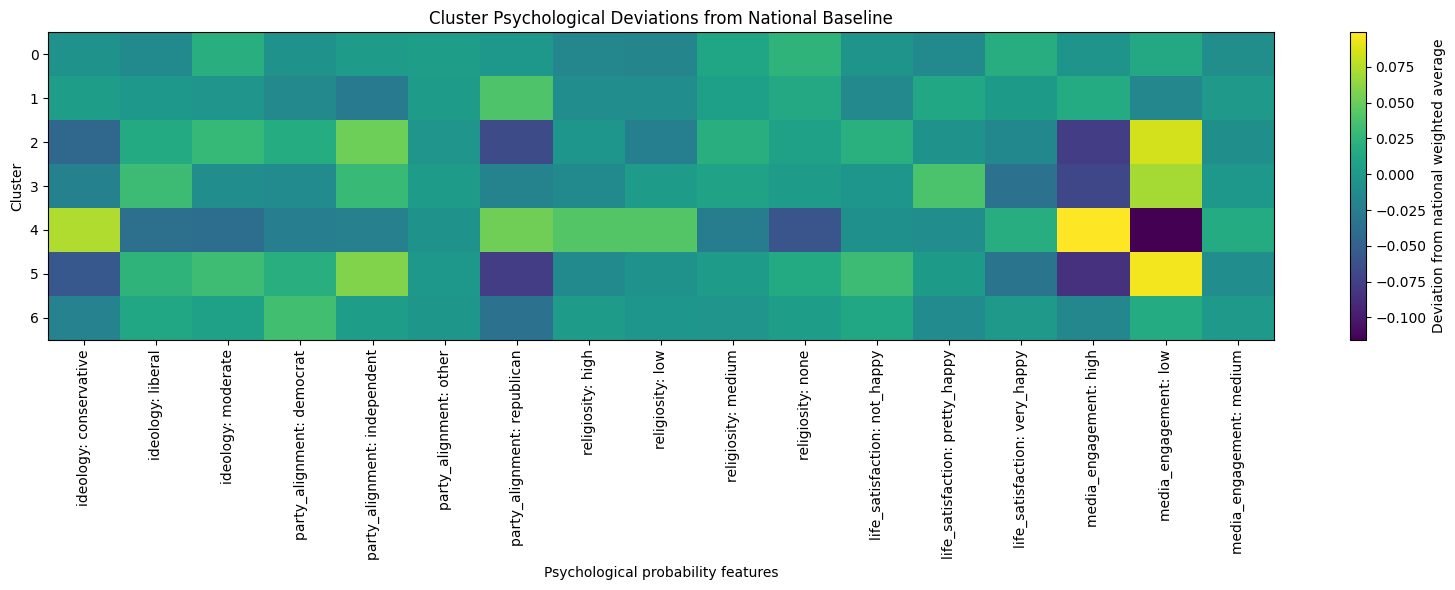

In [25]:
# create cleaner column labels for the heatmap
heatmap_df = cluster_psych_dev.set_index("cluster")[prob_cols].copy()
heatmap_df.columns = [c.replace("__", ": ") for c in heatmap_df.columns]

fig, ax = plt.subplots(figsize=(16, 6))

im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=90)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_title("Cluster Psychological Deviations from National Baseline")
ax.set_xlabel("Psychological probability features")
ax.set_ylabel("Cluster")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Deviation from national weighted average")

plt.tight_layout()
plt.show()

In [26]:
# show strongest positive and negative deviations for each cluster
for cl in heatmap_df.index:
    s = heatmap_df.loc[cl].sort_values()

    print(f"\nCluster {cl}")
    print("Most below baseline:")
    print(s.head(5).round(3))

    print("\nMost above baseline:")
    print(s.tail(5).round(3))


Cluster 0
Most below baseline:
religiosity: low                  -0.018
religiosity: high                 -0.017
life_satisfaction: pretty_happy   -0.014
ideology: liberal                 -0.013
media_engagement: medium          -0.009
Name: 0, dtype: float64

Most above baseline:
religiosity: medium              0.011
media_engagement: low            0.014
life_satisfaction: very_happy    0.019
ideology: moderate               0.020
religiosity: none                0.024
Name: 0, dtype: float64

Cluster 1
Most below baseline:
party_alignment: independent   -0.028
media_engagement: low          -0.016
party_alignment: democrat      -0.014
life_satisfaction: not_happy   -0.014
religiosity: low               -0.010
Name: 1, dtype: float64

Most above baseline:
religiosity: medium                0.006
life_satisfaction: pretty_happy    0.012
religiosity: none                  0.014
media_engagement: high             0.016
party_alignment: republican        0.040
Name: 1, dtype: float64



# Psychological Profile Analysis of Structural Clusters

After aggregating the probabilistic psychological traits at the cluster level, an initial summary table was produced identifying the **dominant category** for each psychological dimension (ideology, party alignment, religiosity, life satisfaction, and media engagement).

However, this first view proved **not very informative**. Because the psychological traits were inferred probabilistically from survey data (GSS) and then projected onto the synthetic ACS population, the resulting cluster averages tended to **converge toward the national baseline distribution**. As a result, most clusters appeared to share the same dominant categories (e.g., "moderate" ideology, "Democrat" party alignment, "pretty happy" life satisfaction), masking potentially meaningful differences between segments.

To reveal the underlying structure, the analysis shifted from examining **absolute probabilities** to analyzing **deviations from the national weighted baseline**. The national baseline for each psychological probability was computed using ACS weights (`pwgtp`), and each cluster’s psychological profile was expressed as the difference between the cluster-level estimate and the national average.

This transformation highlights **relative behavioral tendencies** within each structural segment. Positive values indicate that a trait is **more prevalent in the cluster than in the national population**, while negative values indicate that it is **less prevalent than average**. This deviation-based view revealed clearer patterns across clusters, such as segments that are relatively more conservative, more religious, or more engaged with media than the population baseline.

At this stage, the deviations represent **estimated differences derived from weighted projections**, not direct survey measurements. Because the synthetic population is large and weighted, even small differences may appear meaningful. The next step is therefore to assess whether these deviations are **statistically meaningful relative to sampling variability**.

To do so, a **weighted bootstrap procedure** will be implemented. For each cluster and psychological trait, rows within the cluster will be resampled with replacement (respecting ACS weights), and the weighted mean will be recomputed across many iterations. This will allow the construction of **confidence intervals around the cluster estimates**, enabling us to evaluate whether observed deviations from the national baseline fall outside the expected variability of the estimate.

This step will help distinguish **substantive behavioral signals** from small fluctuations due to sampling noise, strengthening the interpretability of the psychological cluster profiles.

In [27]:
# weighted bootstrap for probability columns
def weighted_bootstrap_mean(df_cluster, col, weights_col="pwgtp", n_boot=300):
    
    values = df_cluster[col].values
    weights = df_cluster[weights_col].values
    
    probs = weights / weights.sum()
    
    boot_means = []
    
    n = len(values)
    
    for _ in range(n_boot):
        idx = np.random.choice(n, size=n, replace=True, p=probs)
        boot_means.append(values[idx].mean())   # IMPORTANT: no weights here
        
    return np.percentile(boot_means, [2.5, 97.5])

In [28]:
cluster_id = 4
col = "ideology__conservative"

df_cluster = df[df["cluster"] == cluster_id]

ci = weighted_bootstrap_mean(df_cluster, col)

cluster_mean = cluster_psych.loc[
    cluster_psych.cluster == cluster_id, col
].values[0]

print("Cluster mean:", cluster_mean)
print("95% CI:", ci)
print("National baseline:", national_psych[col])

Cluster mean: 0.39016453583868876
95% CI: [0.38932727 0.39106646]
National baseline: 0.3166590607270613


In [29]:
# threshold for substantive deviation
threshold = 0.03

# identify substantive deviations
substantive_devs = heatmap_df.where(abs(heatmap_df) >= threshold)

substantive_devs

,ideology: conservative,ideology: liberal,ideology: moderate,party_alignment: democrat,party_alignment: independent,party_alignment: other,party_alignment: republican,religiosity: high,religiosity: low,religiosity: medium,religiosity: none,life_satisfaction: not_happy,life_satisfaction: pretty_happy,life_satisfaction: very_happy,media_engagement: high,media_engagement: low,media_engagement: medium
cluster,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,0.039696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.043829,NaN,NaN,NaN,0.051321,NaN,-0.065359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.076188,0.084677,NaN
3,NaN,0.031761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.038178,-0.035752,-0.069710,0.070493,NaN
4,0.073505,-0.035912,-0.037594,NaN,NaN,NaN,0.052227,0.041519,0.041806,NaN,-0.058769,NaN,NaN,NaN,0.099036,-0.115528,NaN
5,-0.056756,NaN,0.032380,NaN,0.057999,NaN,-0.076317,NaN,NaN,NaN,NaN,0.031469,NaN,-0.033221,-0.085171,0.095377,NaN
6,NaN,NaN,NaN,0.033939,NaN,NaN,-0.035831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# count substantive signals per cluster
signal_counts = (abs(heatmap_df) >= threshold).sum(axis=1)

signal_counts

cluster
0    0
1    1
2    5
3    5
4    9
5    8
6    2
dtype: int64

In [31]:
# list strongest deviations per cluster
for cluster in heatmap_df.index:
    s = heatmap_df.loc[cluster]
    
    strong = s[abs(s) >= threshold].sort_values()
    
    print(f"\nCluster {cluster}")
    print(strong.round(3))


Cluster 0
Series([], Name: 0, dtype: float64)

Cluster 1
party_alignment: republican    0.04
Name: 1, dtype: float64

Cluster 2
media_engagement: high         -0.076
party_alignment: republican    -0.065
ideology: conservative         -0.044
party_alignment: independent    0.051
media_engagement: low           0.085
Name: 2, dtype: float64

Cluster 3
media_engagement: high            -0.070
life_satisfaction: very_happy     -0.036
ideology: liberal                  0.032
life_satisfaction: pretty_happy    0.038
media_engagement: low              0.070
Name: 3, dtype: float64

Cluster 4
media_engagement: low         -0.116
religiosity: none             -0.059
ideology: moderate            -0.038
ideology: liberal             -0.036
religiosity: high              0.042
religiosity: low               0.042
party_alignment: republican    0.052
ideology: conservative         0.074
media_engagement: high         0.099
Name: 4, dtype: float64

Cluster 5
media_engagement: high          -0.085

In [32]:
# build cluster psychological signature table

threshold = 0.03

rows = []

for cluster in heatmap_df.index:
    
    s = heatmap_df.loc[cluster]
    
    strong = s[abs(s) >= threshold].sort_values()
    
    for trait, dev in strong.items():
        
        rows.append({
            "cluster": cluster,
            "trait": trait.replace("__", ": "),
            "deviation": round(dev, 3),
            "direction": "above baseline" if dev > 0 else "below baseline"
        })

cluster_signature = pd.DataFrame(rows)

cluster_signature.sort_values(["cluster", "deviation"], inplace=True)

cluster_signature

,cluster,trait,deviation,direction
0,1,party_alignment: republican,0.040,above baseline
1,2,media_engagement: high,-0.076,below baseline
2,2,party_alignment: republican,-0.065,below baseline
3,2,ideology: conservative,-0.044,below baseline
4,2,party_alignment: independent,0.051,above baseline
5,2,media_engagement: low,0.085,above baseline
6,3,media_engagement: high,-0.070,below baseline
7,3,life_satisfaction: very_happy,-0.036,below baseline
8,3,ideology: liberal,0.032,above baseline
9,3,life_satisfaction: pretty_happy,0.038,above baseline


In [33]:
cluster_signature["abs_dev"] = cluster_signature["deviation"].abs()

cluster_signature.sort_values(["cluster", "abs_dev"], ascending=[True, False], inplace=True)

cluster_signature.drop(columns="abs_dev", inplace=True)

cluster_signature

,cluster,trait,deviation,direction
0,1,party_alignment: republican,0.040,above baseline
5,2,media_engagement: low,0.085,above baseline
1,2,media_engagement: high,-0.076,below baseline
2,2,party_alignment: republican,-0.065,below baseline
4,2,party_alignment: independent,0.051,above baseline
3,2,ideology: conservative,-0.044,below baseline
6,3,media_engagement: high,-0.070,below baseline
10,3,media_engagement: low,0.070,above baseline
9,3,life_satisfaction: pretty_happy,0.038,above baseline
7,3,life_satisfaction: very_happy,-0.036,below baseline


In [34]:
# ------------------------------------------------------------
# Save cluster-level psychological profiles
# ------------------------------------------------------------

OUTPUT_PATH = PROCESSED_DIR / "08_us_cluster_psych_profiles_v1.parquet"

cluster_psych.to_parquet(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print("Shape:", cluster_psych.shape)

Saved: /Users/marcomagnolo/Projects/us-audience-segmentation/data/processed/08_us_cluster_psych_profiles_v1.parquet
Shape: (7, 19)


In [35]:
# ------------------------------------------------------------
# Save cluster psychological signatures
# ------------------------------------------------------------

OUTPUT_PATH = PROCESSED_DIR / "08_us_cluster_psychological_signatures_v1.parquet"

cluster_signature.to_parquet(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print("Shape:", cluster_signature.shape)

Saved: /Users/marcomagnolo/Projects/us-audience-segmentation/data/processed/08_us_cluster_psychological_signatures_v1.parquet
Shape: (30, 4)


In [36]:
# print cluster psychological signatures in grouped form

for cluster in sorted(cluster_signature["cluster"].unique()):
    
    df_c = cluster_signature[cluster_signature["cluster"] == cluster]
    
    above = df_c[df_c["direction"] == "above baseline"].sort_values("deviation", ascending=False)
    below = df_c[df_c["direction"] == "below baseline"].sort_values("deviation")
    
    print(f"\nCluster {cluster}")
    
    if len(above) > 0:
        print("  Above baseline:")
        for _, r in above.iterrows():
            print(f"    {r['trait']}  (+{r['deviation']:.3f})")
    
    if len(below) > 0:
        print("  Below baseline:")
        for _, r in below.iterrows():
            print(f"    {r['trait']}  ({r['deviation']:.3f})")


Cluster 1
  Above baseline:
    party_alignment: republican  (+0.040)

Cluster 2
  Above baseline:
    media_engagement: low  (+0.085)
    party_alignment: independent  (+0.051)
  Below baseline:
    media_engagement: high  (-0.076)
    party_alignment: republican  (-0.065)
    ideology: conservative  (-0.044)

Cluster 3
  Above baseline:
    media_engagement: low  (+0.070)
    life_satisfaction: pretty_happy  (+0.038)
    ideology: liberal  (+0.032)
  Below baseline:
    media_engagement: high  (-0.070)
    life_satisfaction: very_happy  (-0.036)

Cluster 4
  Above baseline:
    media_engagement: high  (+0.099)
    ideology: conservative  (+0.074)
    party_alignment: republican  (+0.052)
    religiosity: high  (+0.042)
    religiosity: low  (+0.042)
  Below baseline:
    media_engagement: low  (-0.116)
    religiosity: none  (-0.059)
    ideology: moderate  (-0.038)
    ideology: liberal  (-0.036)

Cluster 5
  Above baseline:
    media_engagement: low  (+0.095)
    party_alignment: 

# Cluster-Level Psychological Profiles — Results and Interpretation

This notebook enriches the previously identified **structural population clusters** with **psychological characteristics inferred from survey data**. The objective is to transform purely demographic segments into **behaviorally interpretable population segments** that can support downstream audience analysis, messaging strategy, and influence modeling.

---

## Methodology Summary

The psychological profiles of the clusters are derived through the following steps.

### 1. Individual-Level Psychological Projection

Psychological traits (ideology, party alignment, religiosity, life satisfaction, and media engagement) were inferred in the previous notebook using **General Social Survey (GSS)** data.

A probabilistic model estimated the likelihood of each psychological category conditional on structural characteristics such as:

- age group  
- education level  
- income tier  
- employment status  
- marital status  
- household structure  
- housing conditions  

These relationships were learned from the GSS and then applied to the **ACS structural population**, producing **probabilistic psychological profiles for each individual**.

---

### 2. Cluster-Level Aggregation

In this notebook, the individual-level probabilities are aggregated to the cluster level using **ACS person weights (`pwgtp`)**.

This produces a **cluster-level psychological probability distribution** for each trait dimension.

---

### 3. Baseline Deviation Analysis

Because probabilistic projections tend to converge toward the **national population distribution**, raw cluster averages are not sufficiently informative.

To reveal meaningful differences, cluster-level estimates are compared to the **national weighted baseline**.

For each trait:

cluster deviation = cluster probability − national probability

Positive values indicate that a trait is **more prevalent in the cluster than in the national population**, while negative values indicate the opposite.

---

### 4. Substantive Effect Threshold

Given the large size of the synthetic population, many small differences may appear statistically significant.

To focus on **substantively meaningful differences**, a deviation threshold is applied:

|deviation| ≥ 0.03

This corresponds to a **difference of at least three percentage points from the national baseline**.

Only traits exceeding this threshold are retained as **cluster behavioral signals**.

---

## Special Consideration: Child-Dominated Clusters

Two structural clusters contain a **large proportion of minors**:

- **Cluster 2 — Kids in Working Families**
- **Cluster 5 — Dependent Kids in Shared Homes**

Attitudinal surveys such as the **GSS** and **NPORS** collect data only from adults (18+).  
Therefore, psychological traits cannot be directly inferred for minors.

In this analysis, the psychological profile of these clusters reflects the **attitudinal environment of the adults within those households**, not the attitudes of the children themselves.

These segments should therefore be interpreted as **family or household environments**, and their psychological profiles should be used with appropriate caution.

---

## Psychological Signatures of the Clusters

Applying the deviation threshold reveals distinct behavioral patterns across the structural segments.

### Cluster 0 — Baseline Population Segment

This cluster does not display strong deviations from the national baseline.  
It represents a **structurally and psychologically average segment** of the population.

---

### Cluster 1 — Slight Republican Lean

Key signal:

- Higher probability of **Republican party alignment**

This cluster appears to represent a **moderately right-leaning segment**, though differences from the national baseline are relatively small.

---

### Cluster 2 — Disengaged Independent-Leaning Households

Key signals:

- Higher probability of **Independent party alignment**
- Lower probability of **Republican affiliation**
- Lower **media engagement**
- Higher probability of **low media engagement**

This segment appears **politically disengaged and weakly ideological**, with limited media consumption.

Given the large share of children in this cluster, these patterns likely reflect the **information environment of working-family households with dependents**.

---

### Cluster 3 — Mildly Liberal, Low Media Engagement Segment

Key signals:

- Higher probability of **liberal ideology**
- Higher **low media engagement**
- Lower **high media engagement**
- Higher probability of being **pretty happy**, but lower probability of **very happy**

This cluster represents a **moderately satisfied, mildly liberal segment with relatively low information consumption**.

---

### Cluster 4 — Politically Engaged Conservative Segment

This is the **most distinctive cluster psychologically**.

Key signals:

- Higher **conservative ideology**
- Higher **Republican affiliation**
- Higher **religiosity**
- Much higher **high media engagement**
- Much lower **low media engagement**

This segment appears to represent a **high-information, politically engaged, conservative population segment**.

---

### Cluster 5 — Disengaged Shared-Household Segment

Key signals:

- Higher **Independent affiliation**
- Lower **Republican affiliation**
- Lower **conservative ideology**
- Much lower **high media engagement**
- Much higher **low media engagement**
- Slightly higher **life dissatisfaction**

This cluster likely represents **large or shared households with many dependents**, characterized by **low media engagement and weak partisan attachment**.

---

### Cluster 6 — Mild Democratic Lean

Key signals:

- Higher **Democratic affiliation**
- Lower **Republican affiliation**

This cluster represents a **moderately Democratic-leaning segment** without strong deviations in other psychological dimensions.

---

## Output Artifacts

This notebook produces the following analytical artifacts:

- **Cluster psychological probability table** (`cluster_psych`)
- **Deviation matrix relative to the national baseline** (`heatmap_df`)
- **Filtered behavioral signals for each cluster**

Saved as:

`08_us_cluster_psychological_signatures_v1.parquet`

These outputs provide the **psychological characterization of each structural population segment**, forming the basis for the next stage of the analysis: **audience interpretation and persona construction**.